Assigment 2 - Image Processing
Author: Mattias Westermark

Note: Gemini has been used as a sounding board
in accordance with the allowed aids policy.

In [114]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [115]:
FILE_PATH = ("/workspaces/LTU-Programming-Portfolio/d0040e_vt2026/session_ip/Assignment 2 Image Processing/")

FILE_1 = ("BL_Royal_Vincent_of_Beauvais.jpg")    # Part 1 - Image Basics 
FILE_2 = ("flowers_color.png")                   # Part 2 - Sampling and Quantization 
FILE_3 = ("colorchecker4x4.png")                 # Part 3 - Colors and Color Spaces
FILE_4 = ("showthrough.png")                     # Part 4 - Histogram Operations
FILE_5_1 = ("Arvid Wallin-4.png")                # Part 5 - Image Smoothing
FILE_5_2 = ("BL_Royal_Vincent_of_Beauvais.jpg")  # Part 6 - Edge Detectors
FILE_6 = ("BL_Royal_Vincent_of_Beauvais.jpg")    # Part 6 - Edge Detectors
FILE_7 = ("showthrough.png")                     # Part 7 - Morphological Operations
FILE_8 = ("BL_Royal_Vincent_of_Beauvais.jpg")    # Part 8 - Connected Components

Part 1 - Image Basics 

Load the image BL_Royal_Vincent_of_Beauvais.jpg
Crop to rows 5000 to 5600, columns 2400 to 4000 
Using Python query and report height, width and number of planes for the sub-image 
Display the image 
Give it a title with your name and this module number and the date 

In [116]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_1}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

In [117]:
image_cropped = image_color[5000:5600, 2400:4000].copy()

In [118]:
height, width, planes = image_cropped.shape
print("Cropped Image")
print(f"height: {height} rows, width: {width} columns, planes: {planes} planes")

Cropped Image
height: 600 rows, width: 1600 columns, planes: 3 planes


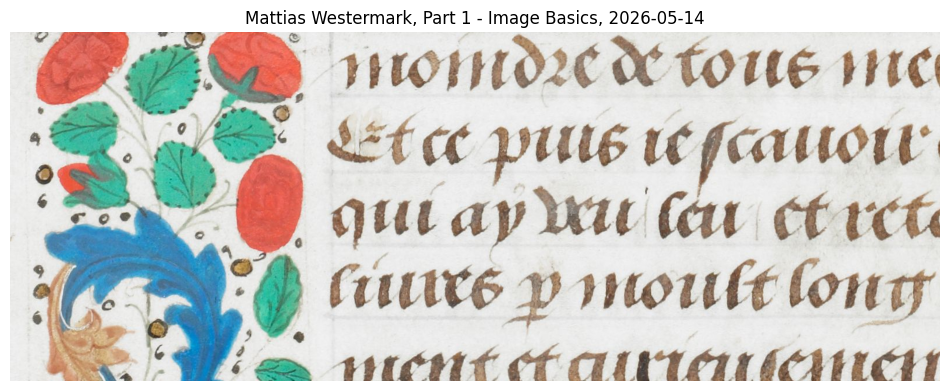

In [119]:
plt.figure(figsize=(12,6))
plt.imshow(image_cropped)
plt.title("Mattias Westermark, Part 1 - Image Basics, 2026-05-14")
plt.axis("off")
plt.show()

Part 2 - Sampling and Quantization 

Load the image flowers_color.png 
Downsample it by a factor of 4 and display it 
Upsample the downsampled image with Nearest Neighbor and display it 
Upsample the downsampled image with Cubic interpolation and display it 

In [120]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_2}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

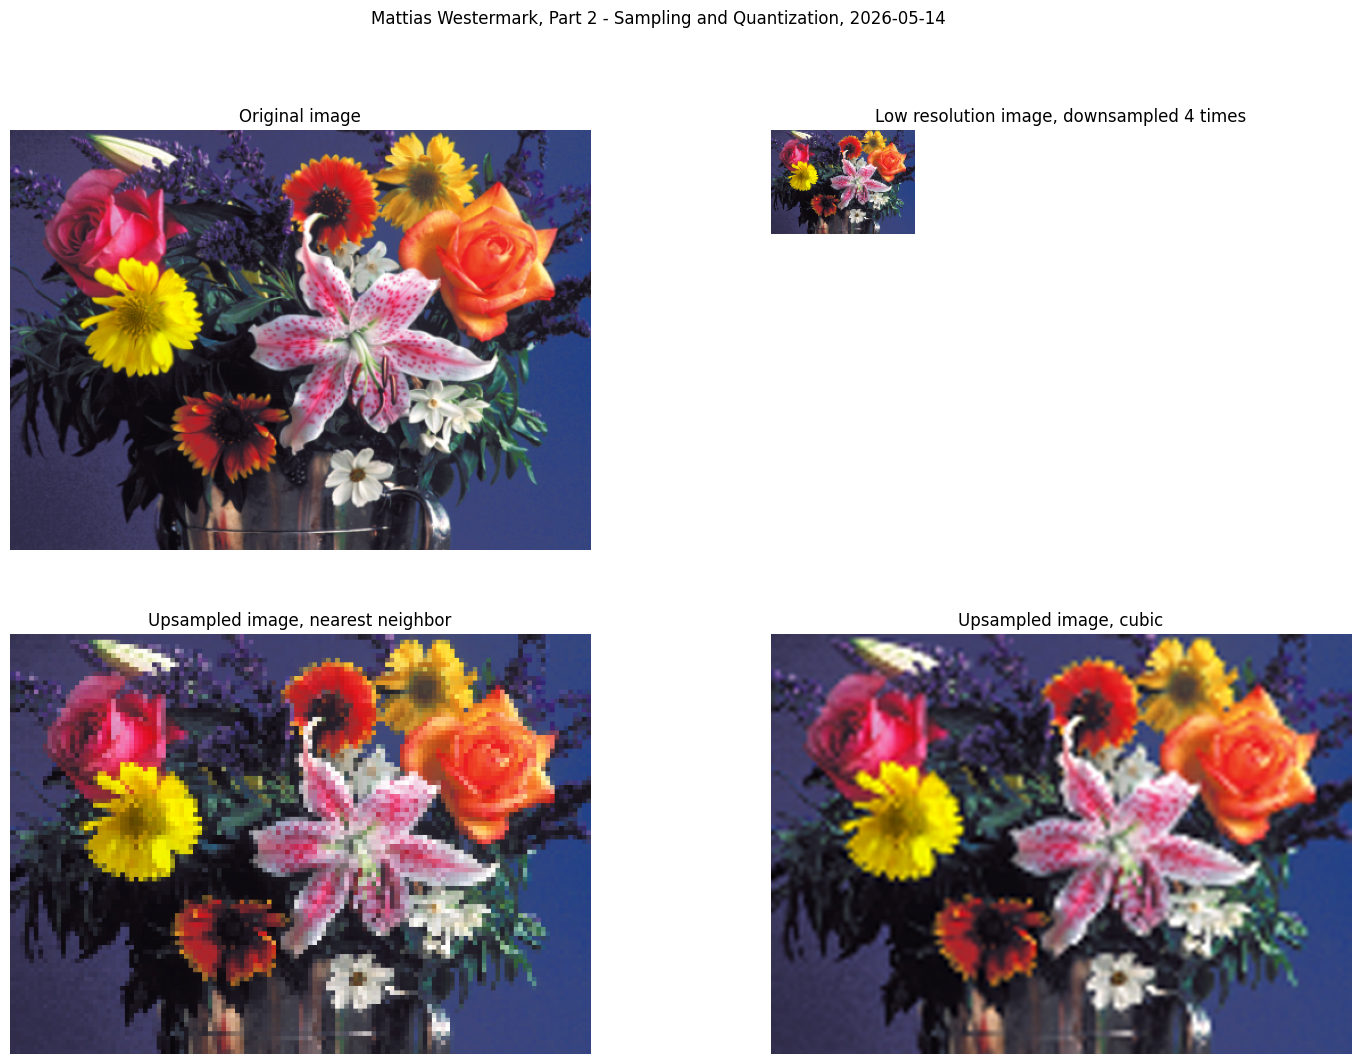

In [121]:
height, width, _ = image_color.shape

low_res_image = cv2.resize(image_color, (width//4, height//4))
upsample_image_neighbor = cv2.resize(low_res_image, (width, height), interpolation=cv2.INTER_NEAREST)
upsample_image_cubic = cv2.resize(low_res_image, (width, height), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(18,12))
plt.suptitle("Mattias Westermark, Part 2 - Sampling and Quantization, 2026-05-14")

plt.subplot(2,2,1)
plt.imshow(image_color)
plt.title("Original image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(low_res_image)
plt.title("Low resolution image, downsampled 4 times")
plt.axis("off")
plt.xlim(0, width)
plt.ylim(height, 0)

plt.subplot(2,2,3)
plt.imshow(upsample_image_neighbor)
plt.title("Upsampled image, nearest neighbor")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(upsample_image_cubic)
plt.title("Upsampled image, cubic")
plt.axis("off")

plt.show()

Part 3 - Colors and Color Spaces 

Load color checker image colorchecker4x4.png 
Display the original color image, then separately display the red, blue, green channels of the image 
Give it a title with your name and this module number and the date 
In the third row, which tiles are white in the red colorplane image? 
In the third row, which tiles are white in the green colorplane image? 
In the third row, which tiles are white in the blue colorplane image? 
You can answer by stating column number or by name {blue, green, red, yellow, magenta, cyan} 
Convert it to gray and display. Which tile in the first row has a grayscale intensity visually closest to the third tile in the last (gray scale) row?

In [122]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_3}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

image_channelR = image_color[:, :, 0]
image_channelG = image_color[:, :, 1]
image_channelB = image_color[:, :, 2]

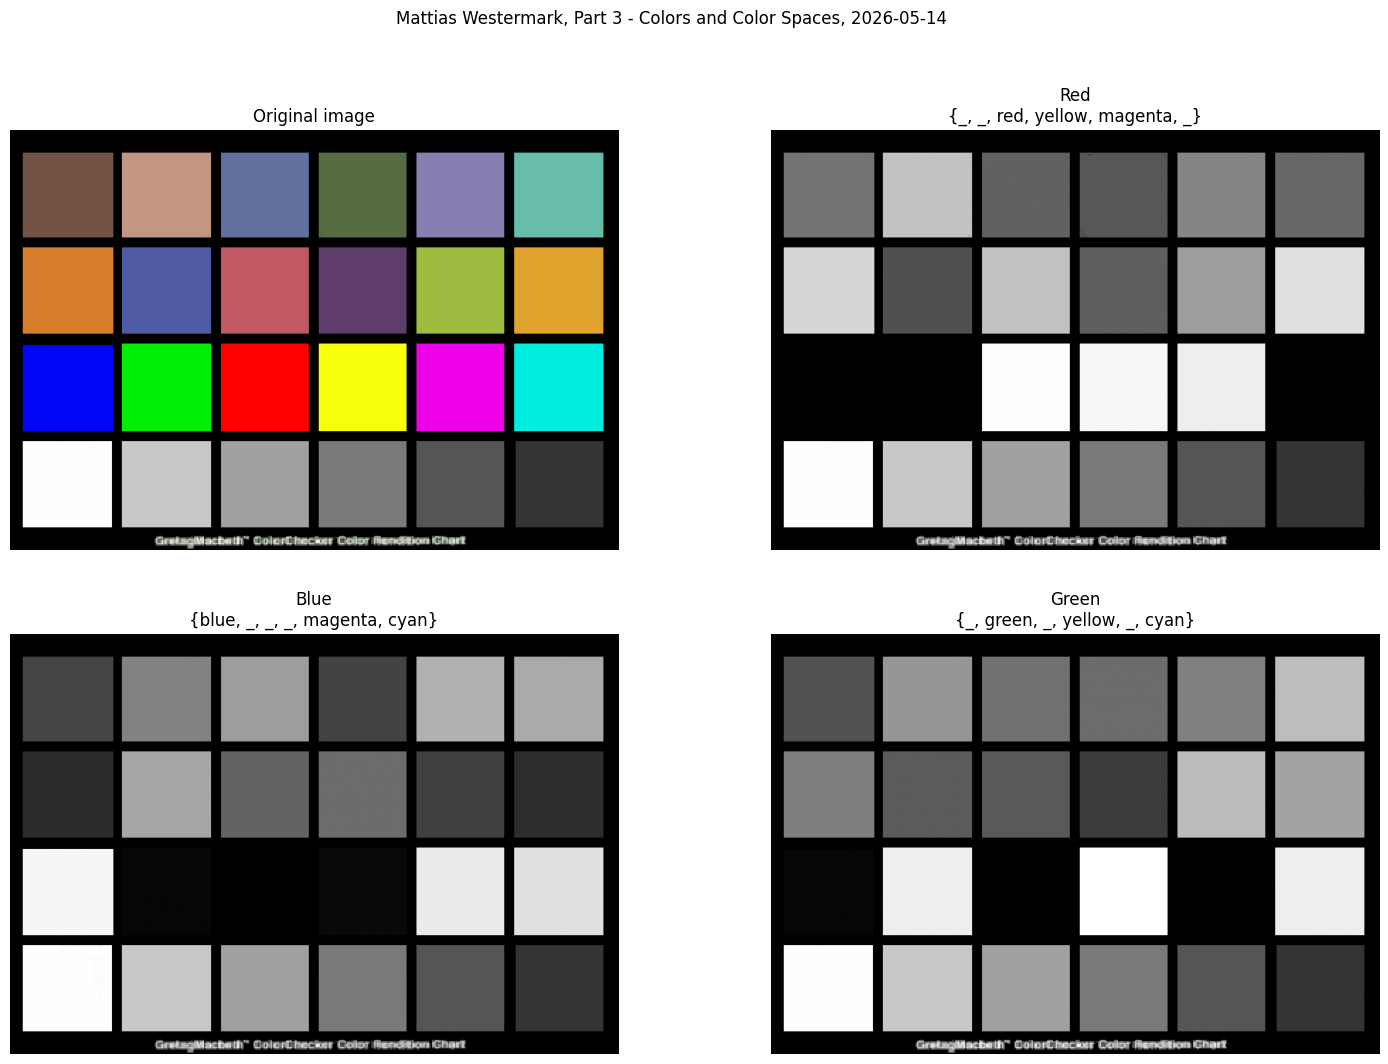

In [123]:
plt.figure(figsize=(18,12))
plt.suptitle("Mattias Westermark, Part 3 - Colors and Color Spaces, 2026-05-14")

plt.subplot(2,2,1)
plt.imshow(image_color)
plt.title("Original image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(image_channelR, cmap="gray")
plt.title("Red\n{_, _, red, yellow, magenta, _}")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(image_channelB, cmap="gray")
plt.title("Blue\n{blue, _, _, _, magenta, cyan}")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(image_channelG, cmap="gray")
plt.title("Green\n{_, green, _, yellow, _, cyan}")
plt.axis("off")

plt.show()

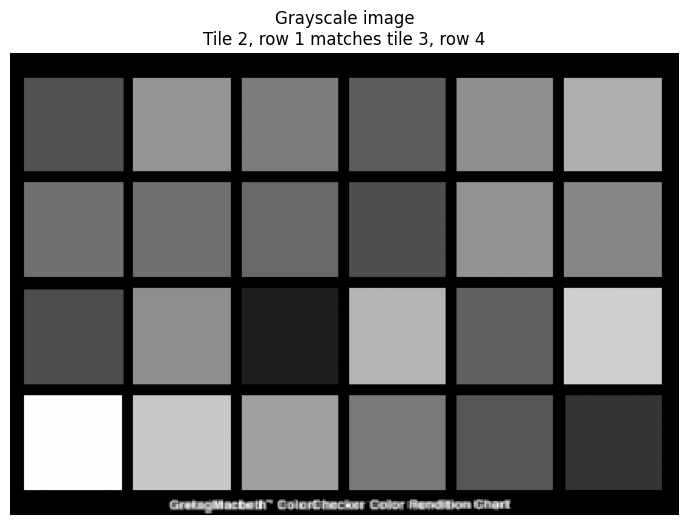

In [124]:
plt.figure(figsize=(12,6))
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale image\nTile 2, row 1 matches tile 3, row 4")
plt.axis("off")
plt.show()

Part 4 - Histogram Operations 

Load the image showthrough.png 
Display an intensity histogram of the image 
Pick and apply a threshold so 
(a) all text, front and show through, is black and paper is white 
(b) only front text is visible and displayed black and paper is white 
Stretch the contrast using only intensities greater than the threshold in (b). Only the darker, front side text should be visible - This is similar to 3b, but the result should be a gray scale image. 
Display an intensity histogram of the contrast stretched image 

In [125]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_4}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

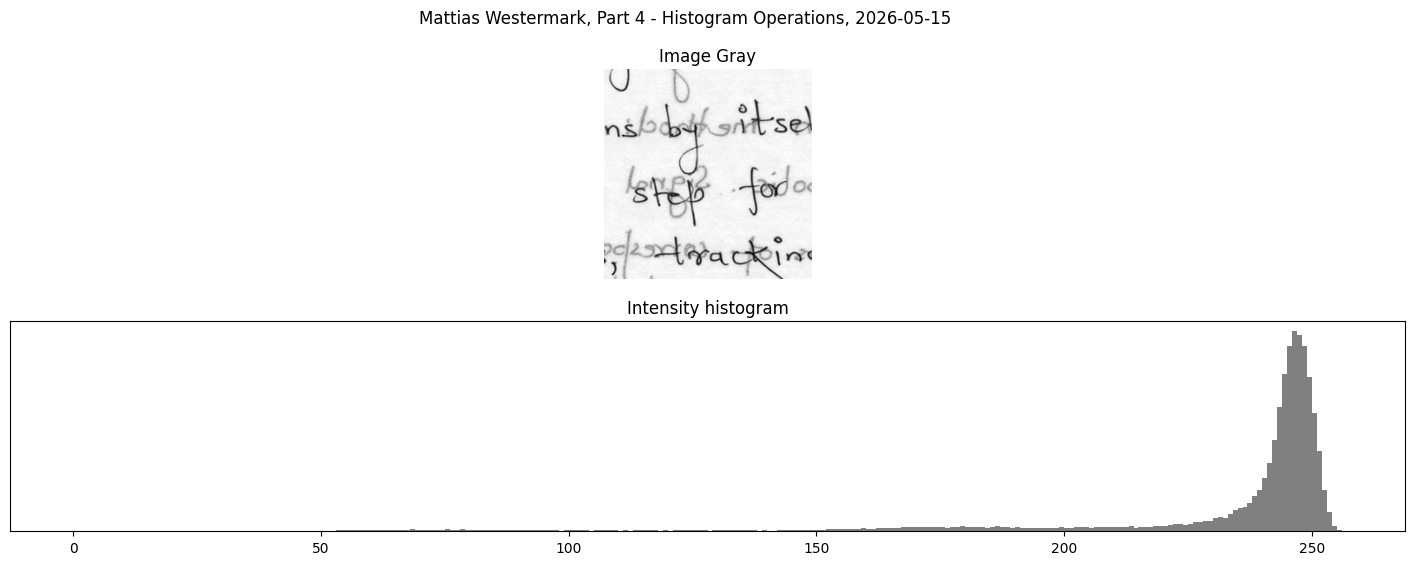

In [126]:
plt.figure(figsize=(18,6))
plt.suptitle("Mattias Westermark, Part 4 - Histogram Operations, 2026-05-15")

plt.subplot(2, 1, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Image Gray")
plt.axis('off')

plt.subplot(2,1,2)
plt.hist(image_gray.ravel(), bins=256, range=[0,256], color="gray")
plt.title("Intensity histogram")
plt.yticks([])

plt.show()

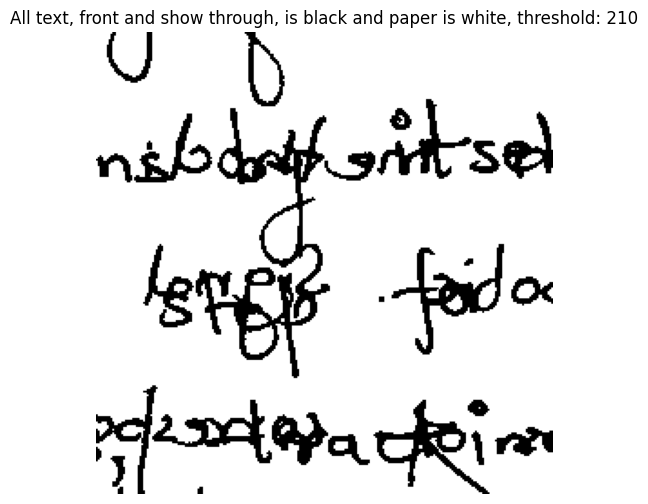

In [127]:
threshold_value = 210
_, image_bilevel = cv2.threshold(image_gray, threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,6))
plt.imshow(image_bilevel, cmap="gray")
plt.title(f"All text, front and show through, is black and paper is white, threshold: {threshold_value}")
plt.axis("off")
plt.show()

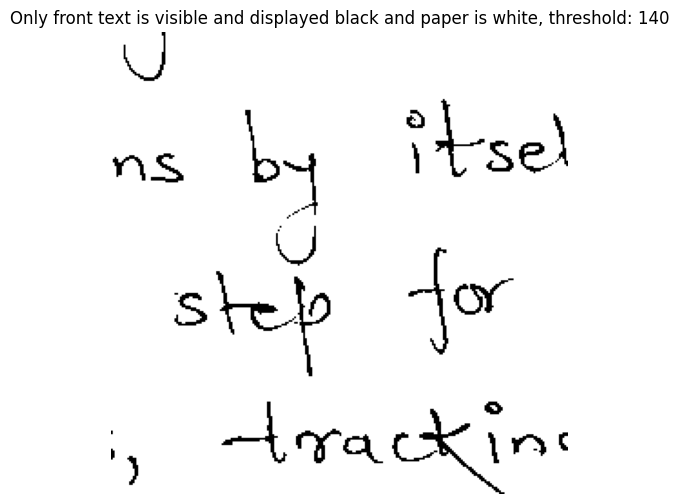

In [128]:
threshold_value = 140
_, image_bilevel = cv2.threshold(image_gray, threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(18,6))
plt.imshow(image_bilevel, cmap="gray")
plt.title(f"Only front text is visible and displayed black and paper is white, threshold: {threshold_value}")
plt.axis("off")
plt.show()

val_min: 33.0, val_max: 140.0


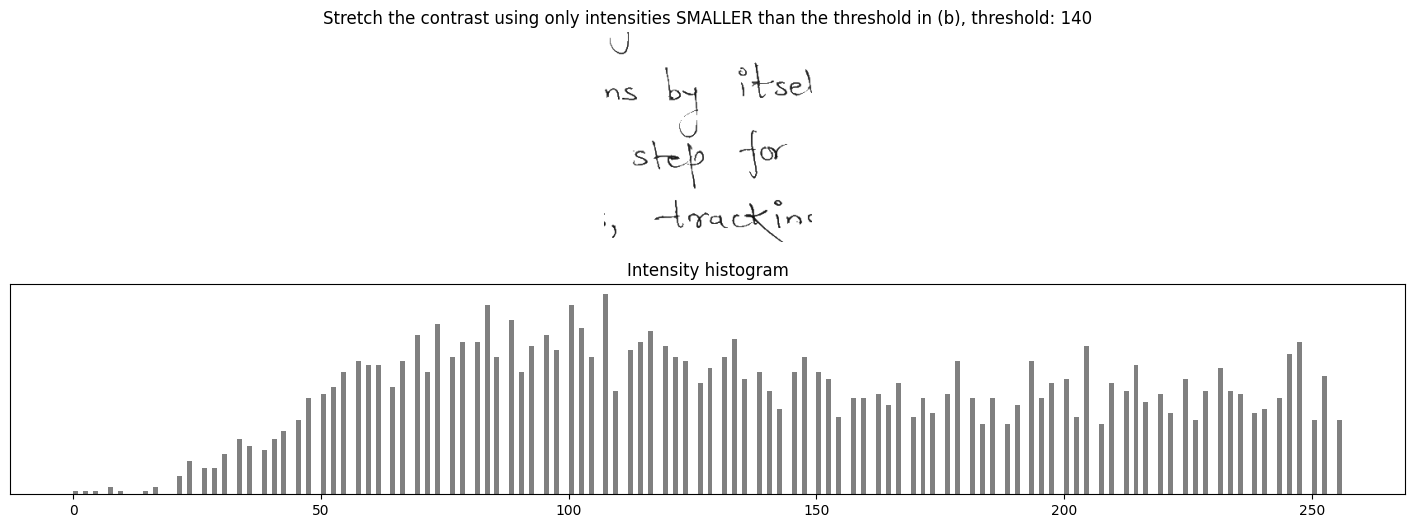

In [129]:
image_stretch = image_gray.copy()
image_stretch[image_stretch > threshold_value] = 255

val_min = float(image_stretch.min())
val_max = float(threshold_value)

print(f"val_min: {val_min}, val_max: {val_max}")

image_stretch = 255 * (np.float32(image_stretch)-val_min)/(val_max-val_min)

plt.figure(figsize=(18,6))

plt.subplot(2,1,1)
plt.imshow(image_stretch, cmap="gray")
plt.title(f"Stretch the contrast using only intensities SMALLER than the threshold in (b), threshold: {threshold_value}")
plt.axis("off")

plt.subplot(2,1,2)
plt.hist(image_stretch.ravel(), bins=256, range=[0,256], color="gray")
plt.title("Intensity histogram")
plt.yticks([])

plt.show()

Part 5 - Image Smoothing

Load image Arvid Wallin-4.png 
Crop to 80:200 (x), 90:210 (y)  
Apply Gaussian Blur to smoothen the image 
Kernel size 5x5, SigmaX = 1 
Kernel size 5x5, SigmaX = 3 
Kernel size 3x3, SigmaX = 1 
Apply cv2.bilateralFilter with settings 6, 25, 25 

Apply a motion blur
Load image BL_Royal_Vincent_of_Beauvais.jpg 
Crop to 2100:2800 (x), 1700:2700 (y)
Define motion blur filter by creating a normalized kernel of ones(1,50) and apply to image with cv2.filter2D 
Display result 
(optional) Define motion blur filter by creating a normalized kernel of ones(50,1) and apply to image with cv2.filter2D 

In [130]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_5_1}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

In [131]:
image_cropped = image_color[80:200, 90:210].copy()

In [132]:
gaussian_blur_551 = cv2.GaussianBlur(image_cropped, ksize=(5,5), sigmaX=1)
gaussian_blur_553 = cv2.GaussianBlur(image_cropped, ksize=(5,5), sigmaX=3)
gaussian_blur_331 = cv2.GaussianBlur(image_cropped, ksize=(3,3), sigmaX=1)

bilaterial_blur = cv2.bilateralFilter(image_cropped, 6, 25, 25)

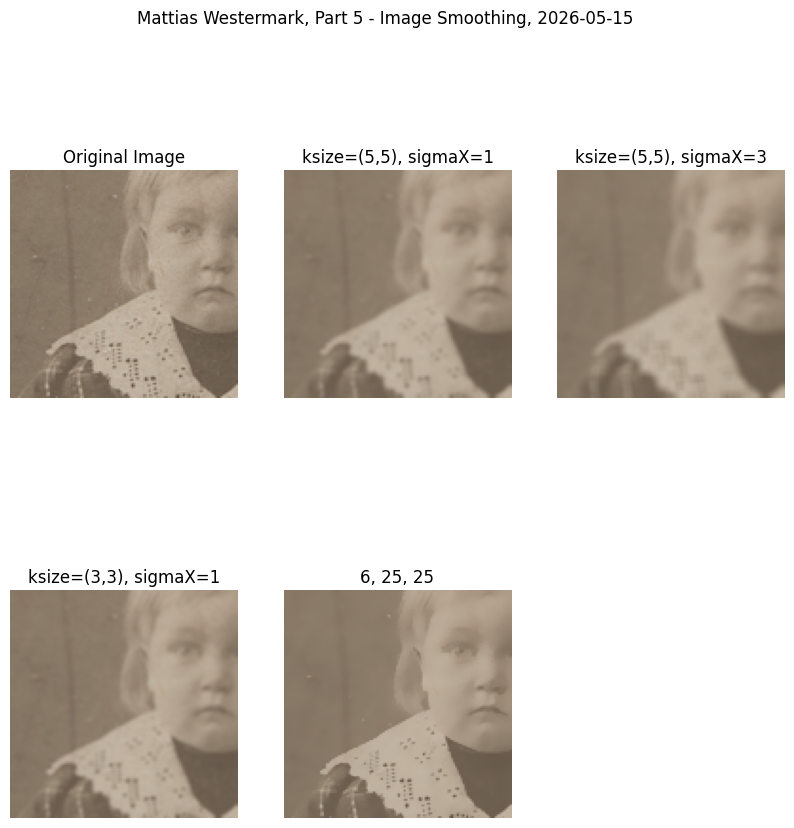

In [ ]:
plt.figure(figsize=(10,10))
plt.suptitle("Mattias Westermark, Part 5.1 - Image Smoothing, 2026-05-15")

plt.subplot(2,3,1)
plt.imshow(image_cropped)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gaussian_blur_551)
plt.title("ksize=(5,5), sigmaX=1")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(gaussian_blur_553)
plt.title("ksize=(5,5), sigmaX=3")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(gaussian_blur_331)
plt.title("ksize=(3,3), sigmaX=1")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(bilaterial_blur)
plt.title("6, 25, 25")
plt.axis("off")

plt.show()

In [137]:
image_in = cv2.imread(f"{FILE_PATH}{FILE_5_2}")
image_color = cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

In [138]:
image_cropped = image_color[1700:2700, 2100:2800].copy()

In [159]:
kernel_horizontal = np.ones((1,50), np.float32)/50
image_smooth_horizontal = cv2.filter2D(image_cropped, -1, kernel_horizontal)

kernel_vertical = np.ones((50,1), np.float32)/50
image_smooth_vertical = cv2.filter2D(image_cropped, -1, kernel_vertical)

kernel_diagonal = np.eye(50, dtype=np.float32)/50
image_smooth_diagonal = cv2.filter2D(image_cropped, -1, kernel_diagonal)

kernel_random = np.random.rand(50, 50).astype(np.float32)
kernel_random /= kernel_random.sum()
image_random = cv2.filter2D(image_cropped, -1, kernel_random)

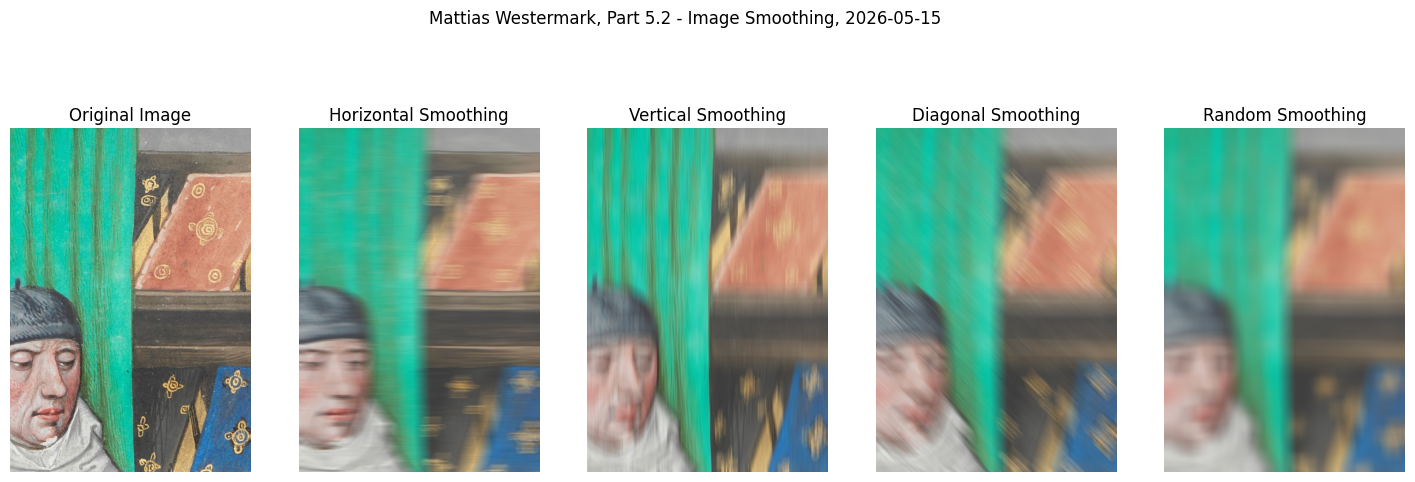

In [161]:
plt.figure(figsize=(18,6))
plt.suptitle("Mattias Westermark, Part 5.2 - Image Smoothing, 2026-05-15")

plt.subplot(1,5,1)
plt.imshow(image_cropped)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(image_smooth_horizontal)
plt.title("Horizontal Smoothing")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(image_smooth_vertical)
plt.title("Vertical Smoothing")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(image_smooth_diagonal)
plt.title("Diagonal Smoothing")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(image_random)
plt.title("Random Smoothing")
plt.axis("off")

plt.show()